In [289]:
import numpy as np
import matplotlib.pyplot as plt

Visualisation

In [290]:
def plot_signal_and_psd(t, x, x_filtered, fs, cutoff, b, a):
    """
    Plots:
    - Original and filtered signals (time domain)
    - Power Spectral Density (PSD)
    - Filter frequency response (if b and a are given)

    Parameters:
        t          : np.array, time vector
        x          : np.array, original signal
        x_filtered : np.array, filtered signal
        fs         : float, sampling frequency in Hz
        cutoff     : float, cutoff frequency in Hz
        b, a       : filter coefficients (optional, for freq response plot)
    """
    fig, axs = plt.subplots(3, 1, figsize=(12, 8))

    # --- Time-Domain Plot ---
    axs[0].plot(t, x, label="Original Signal", alpha=0.5)
    axs[0].plot(t, x_filtered, label="Filtered Signal")
    axs[0].set_title("Signal x(t)")
    axs[0].set_xlabel("time [s]")
    axs[0].set_ylabel("Amplitude")
    axs[0].grid(True)
    axs[0].legend()

    # --- Frequency-Domain Plot (PSD) ---
    axs[1].psd(x, NFFT=512, Fs=fs, label="Original Signal")
    axs[1].psd(x_filtered, NFFT=512, Fs=fs, label="Filtered Signal")
    for f in cutoff:
        axs[1].axvline(f, color='red', linestyle='--', label=f'Cutoff: {f} Hz')
    axs[1].set_title("Power Spectral Density")
    axs[1].legend()

    w, h = signal.freqz(b, a, worN=8000, fs=fs)
    for f in cutoff:
        axs[2].axvline(f, color='red', linestyle='--', label=f'Cutoff: {f} Hz')
    axs[2].plot(w, 20 * np.log10(abs(h)), label="Filter Response")
    axs[2].set_title("Filter Frequency Response")
    axs[2].set_xlabel("Frequency [Hz]")
    axs[2].set_ylabel("Magnitude [dB]")
    axs[2].grid(True)
    axs[2].legend()

    plt.tight_layout()
    plt.show()


# Zad 1

Filter the signal using FIR and IIR high-pass, low-pass, and band-pass filters. Present the signals and their spectra before and after filtering, and calculate the SNR (Signal-to-Noise ratio).

In [291]:
def print_SNR(x):
    """
    Prints the Signal-to-Noise Ratio (SNR).

    Parameters:
        x          : np.array, original signal
    """
    print("SNR: {:.5f}".format(np.mean(x)/np.std(x)))

In [292]:
N = 2000
A = 5
f = 5
fs = 1000

In [293]:
dt = 1 / fs  # sampling period
t = dt * np.arange(N)  # sampling time vector
x = A * np.sin(2 * np.pi * f * t) + A * np.random.randn(N)  # noisy signal

Obtained signal

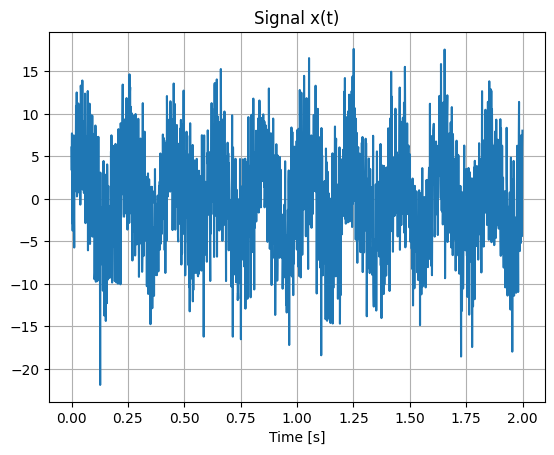

In [294]:
plt.plot(t, x)
plt.grid(True)
plt.title("Signal x(t)")
plt.xlabel("Time [s]")
plt.show()

In [295]:
print_SNR(x)

SNR: 0.00194


Filter FIR

In [296]:
import scipy.signal as signal

In [297]:
# FIR filter design
numtaps = 90  # Number of filter taps (more taps = sharper filter)
cutoff = np.array([10])    # Cutoff frequency in Hz
fir_coeff = signal.firwin(numtaps, cutoff, fs=fs)

In [298]:
# Apply filter
x_filtered = signal.lfilter(fir_coeff, 1.0, x)

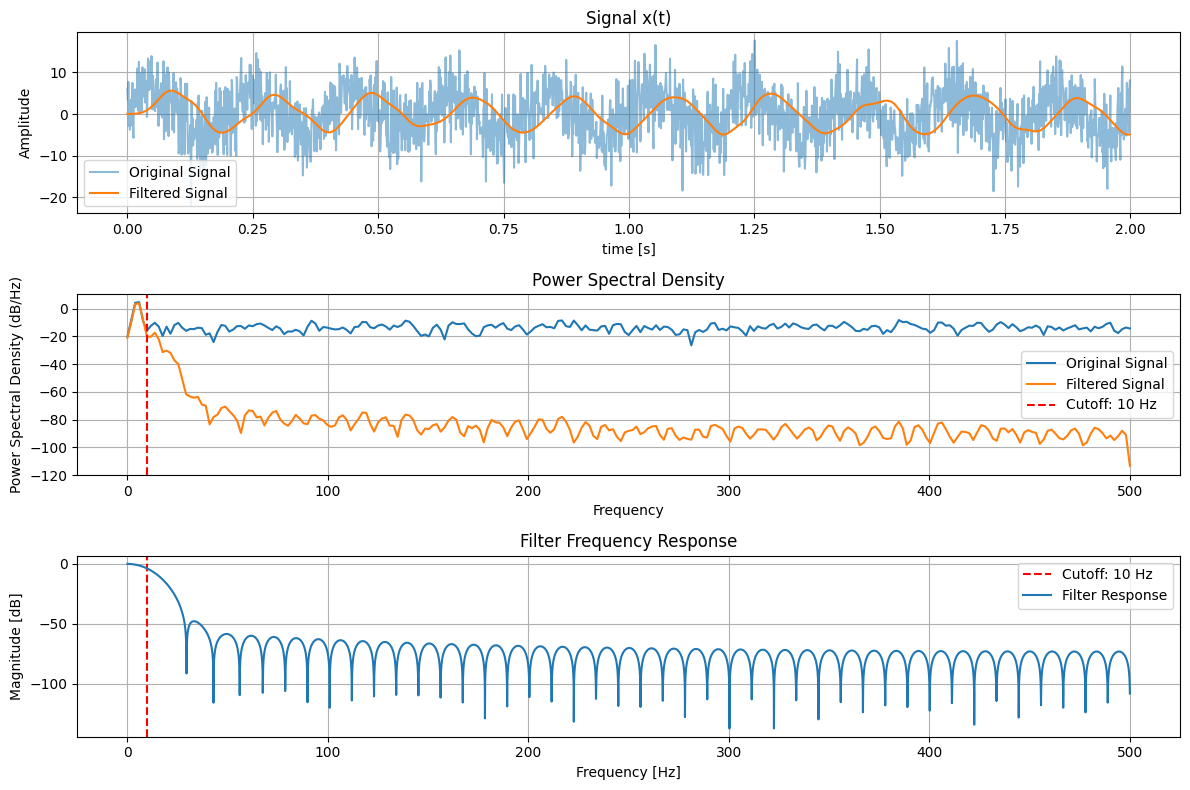

In [299]:
plot_signal_and_psd(t, x, x_filtered, fs, cutoff, fir_coeff, 1.0)

In [300]:
print_SNR(x_filtered)

SNR: 0.02051


### Filter IIR
low-pass

In [301]:
order = 3
cutoff = np.array([10])
b, a = signal.butter(order, cutoff, fs=fs, btype='low')

In [302]:
x_filtered = signal.filtfilt(b, a, x)

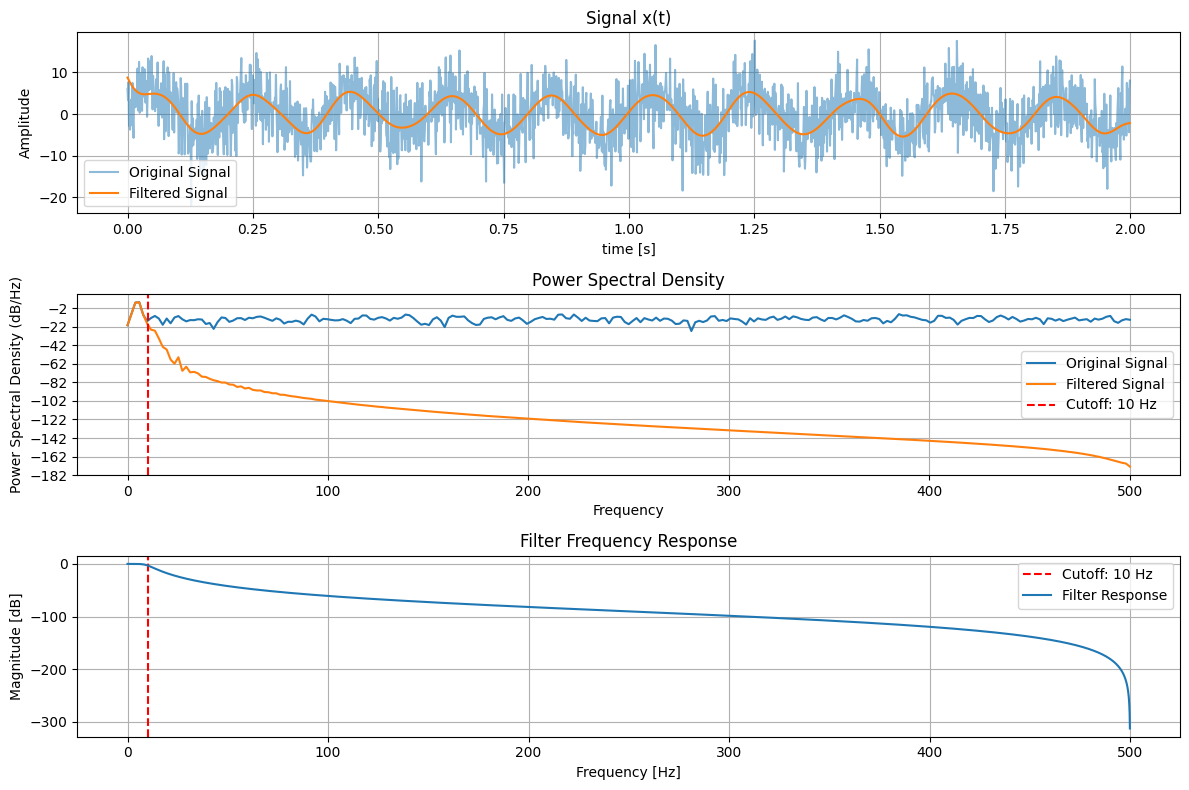

In [303]:
plot_signal_and_psd(t, x, x_filtered, fs, cutoff, b, a)

In [304]:
print_SNR(x_filtered)

SNR: 0.00636


high-pass

In [305]:
order = 3
cutoff = np.array([15])
b, a = signal.butter(order, cutoff, fs=fs, btype='high')

In [306]:
x_filtered = signal.filtfilt(b, a, x)

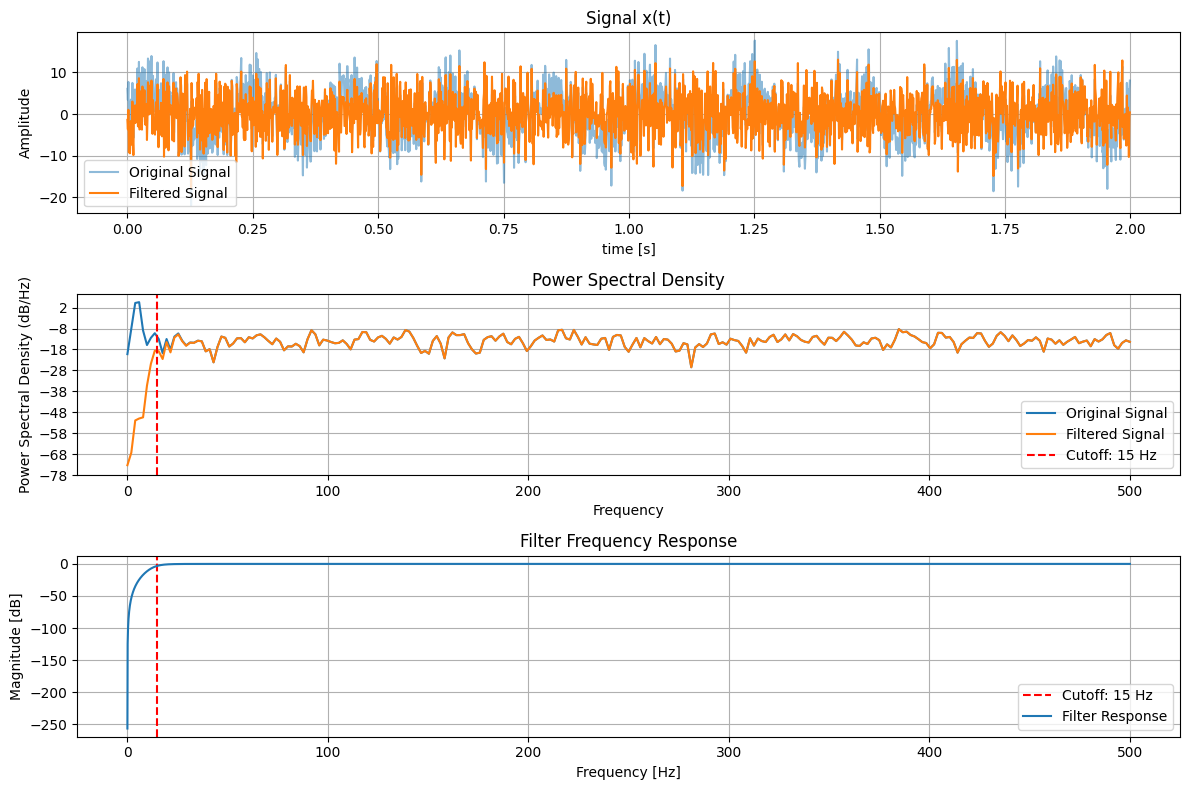

In [307]:
plot_signal_and_psd(t, x, x_filtered, fs, cutoff, b, a)

In [308]:
print_SNR(x_filtered)

SNR: -0.00485


Band-Pass


In [309]:
order = 3
cutoffs = np.array([15,100])
b, a = signal.butter(order, cutoffs, fs=fs, btype='bandpass')

In [310]:
x_filtered = signal.filtfilt(b, a, x)

/tmp/ipykernel_5286/3064605586.py:38: RuntimeWarning: divide by zero encountered in log10
  axs[2].plot(w, 20 * np.log10(abs(h)), label="Filter Response")


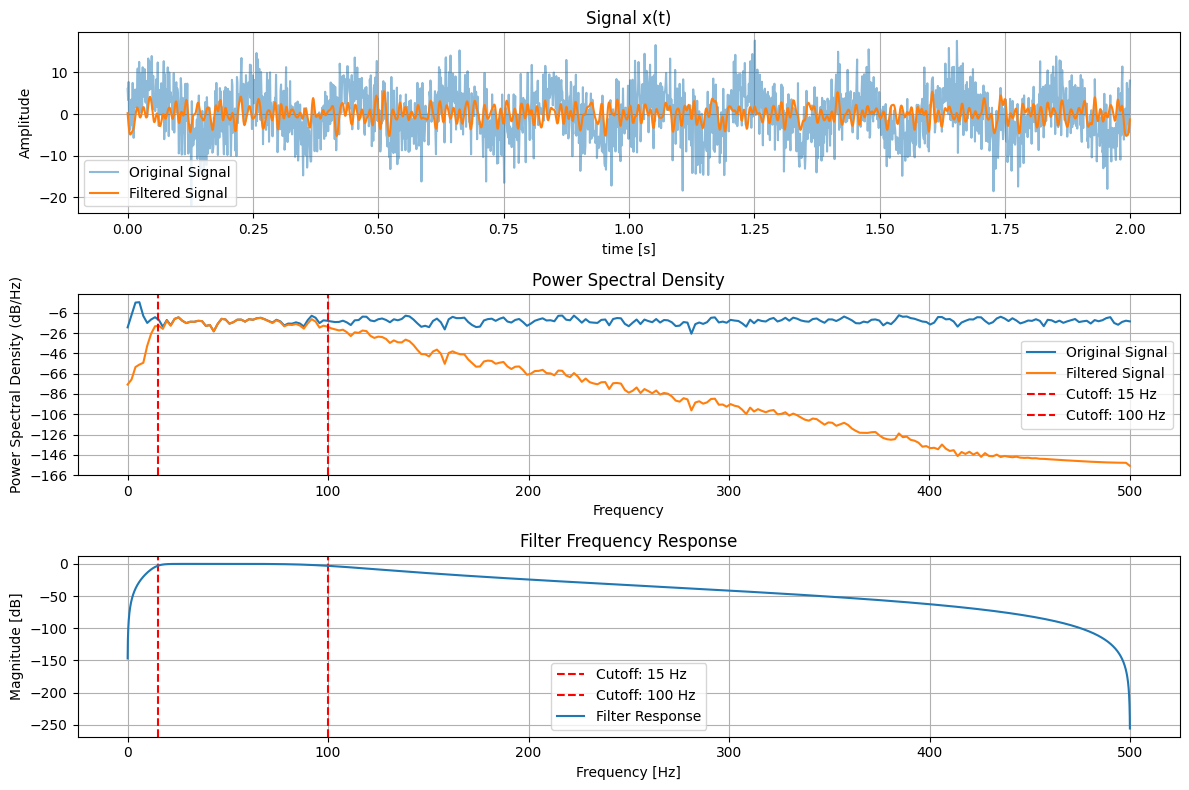

In [311]:
plot_signal_and_psd(t, x, x_filtered, fs, cutoffs, b, a)

In [312]:
print_SNR(x_filtered)

SNR: -0.01697


# Zad 2

In [313]:
N = 2000
A = 5
f1 = 5
f2 = 50
fs = 1000


In [314]:
dt = 1 / fs  # sampling period
t = dt * np.arange(N)  # sampling time vector
y = A * np.sin(2 * np.pi * f1 * t) + 2 * np.sin(10 * np.pi * f2 * t)  # signal

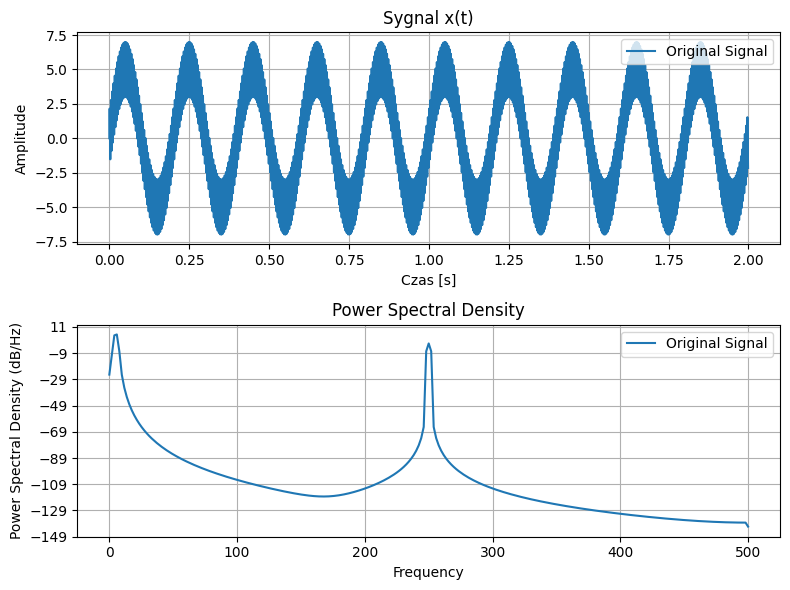

In [315]:
fig, axs = plt.subplots(2, 1, figsize=(8, 6))

# --- Time-Domain Plot ---
axs[0].plot(t, y, label="Original Signal")
axs[0].set_title("Sygnal x(t)")
axs[0].set_xlabel("Czas [s]")
axs[0].set_ylabel("Amplitude")
axs[0].grid(True)
axs[0].legend()

# --- Frequency-Domain Plot (PSD) ---
axs[1].psd(y, NFFT=512, Fs=fs, label="Original Signal")
axs[1].set_title("Power Spectral Density")
axs[1].legend()

plt.tight_layout()
plt.show()


Lower Freq Sin

In [316]:
order = 3
cutoff = np.array([15])
b, a = signal.butter(order, cutoff, fs=fs, btype='low')

y_filtered = signal.filtfilt(b, a, y)

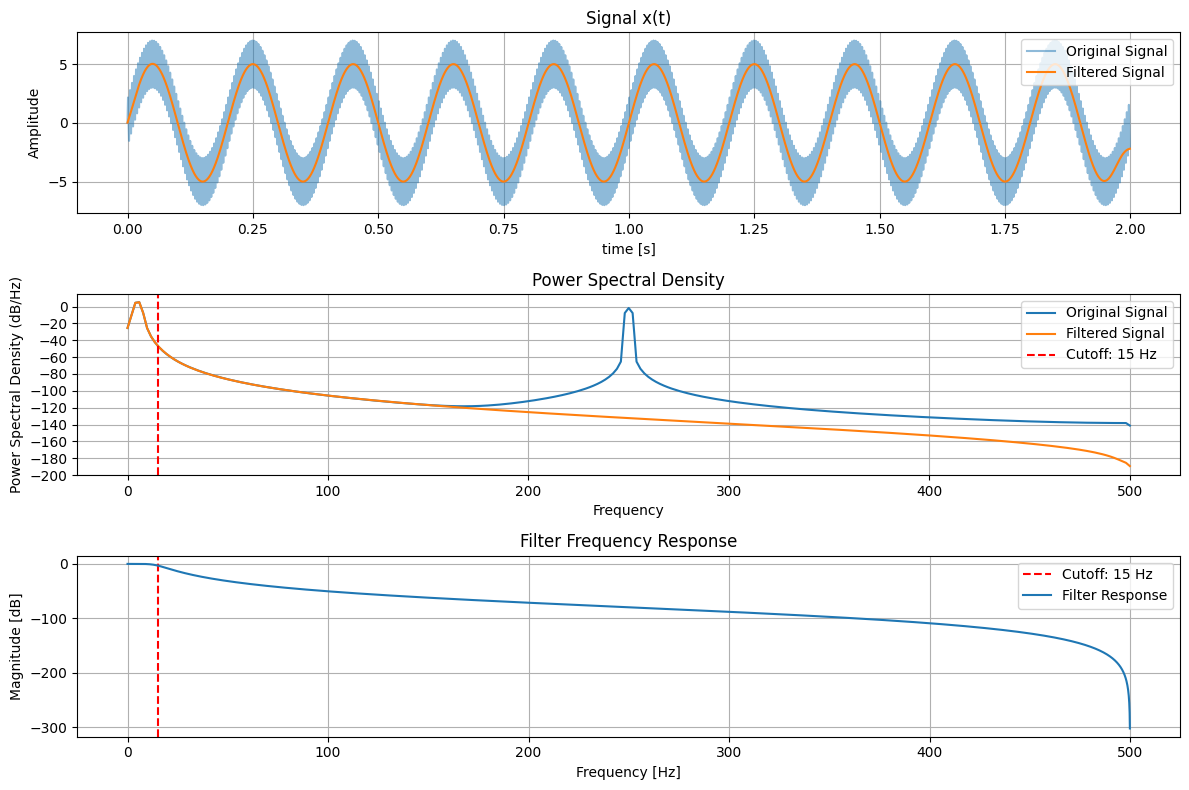

In [317]:
plot_signal_and_psd(t, y, y_filtered, fs, cutoff, b, a)

In [318]:
order = 3
cutoffs = np.array([225,275])
b, a = signal.butter(order, cutoffs, fs=fs, btype='bandpass')

y_filtered = signal.filtfilt(b, a, y)

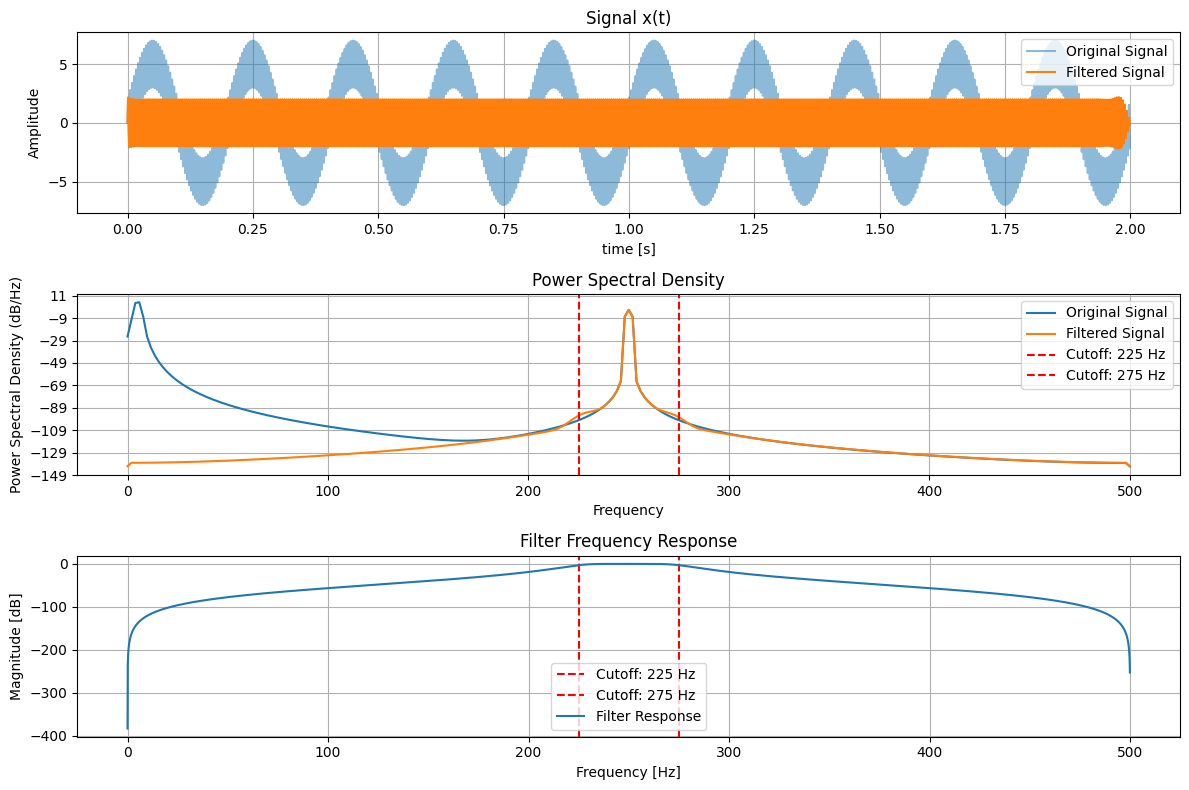

In [319]:
plot_signal_and_psd(t, y, y_filtered, fs, cutoffs, b, a)

# Zad 3

In [398]:
from scipy.io import loadmat

data = loadmat('ecg.mat')

# To see the keys (variables stored in the file)
print(data.keys())


dict_keys(['__header__', '__version__', '__globals__', 'ecg'])


In [399]:
ecg_signal = data['ecg'].reshape(-1)  # Reshape to 1D array
n = np.arange(len(ecg_signal))
fs = 500
t = n / fs  # time vector

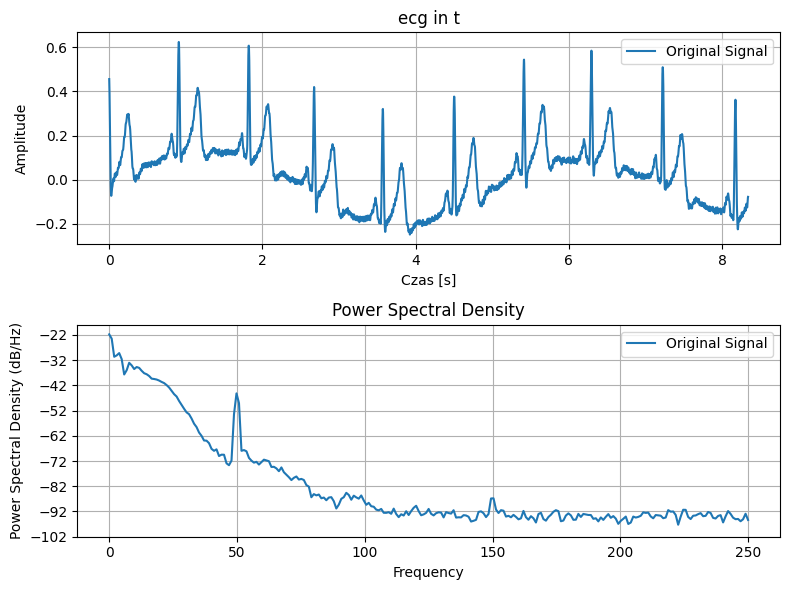

In [400]:
fig, axs = plt.subplots(2, 1, figsize=(8, 6))

# --- Time-Domain Plot ---
axs[0].plot(t, ecg_signal, label="Original Signal")
axs[0].set_title("ecg in t")
axs[0].set_xlabel("Czas [s]")
axs[0].set_ylabel("Amplitude")
axs[0].grid(True)
axs[0].legend()

# --- Frequency-Domain Plot (PSD) ---
axs[1].psd(ecg_signal, NFFT=512, Fs=fs, label="Original Signal")
axs[1].set_title("Power Spectral Density")
axs[1].legend()

plt.tight_layout()
plt.show()


First filter will get rid of baseline wander. Frequency of base line wonder normaly is about 0.5s and below. Order 5 was used to obtain strong filter and was set on 1.5Hz to have time to take effect.

In [450]:
order = 5
cutoffs = np.array([1.5])
b, a = signal.butter(order, cutoffs, fs=fs, btype='high')

ecg_filtered = signal.filtfilt(b, a, ecg_signal)

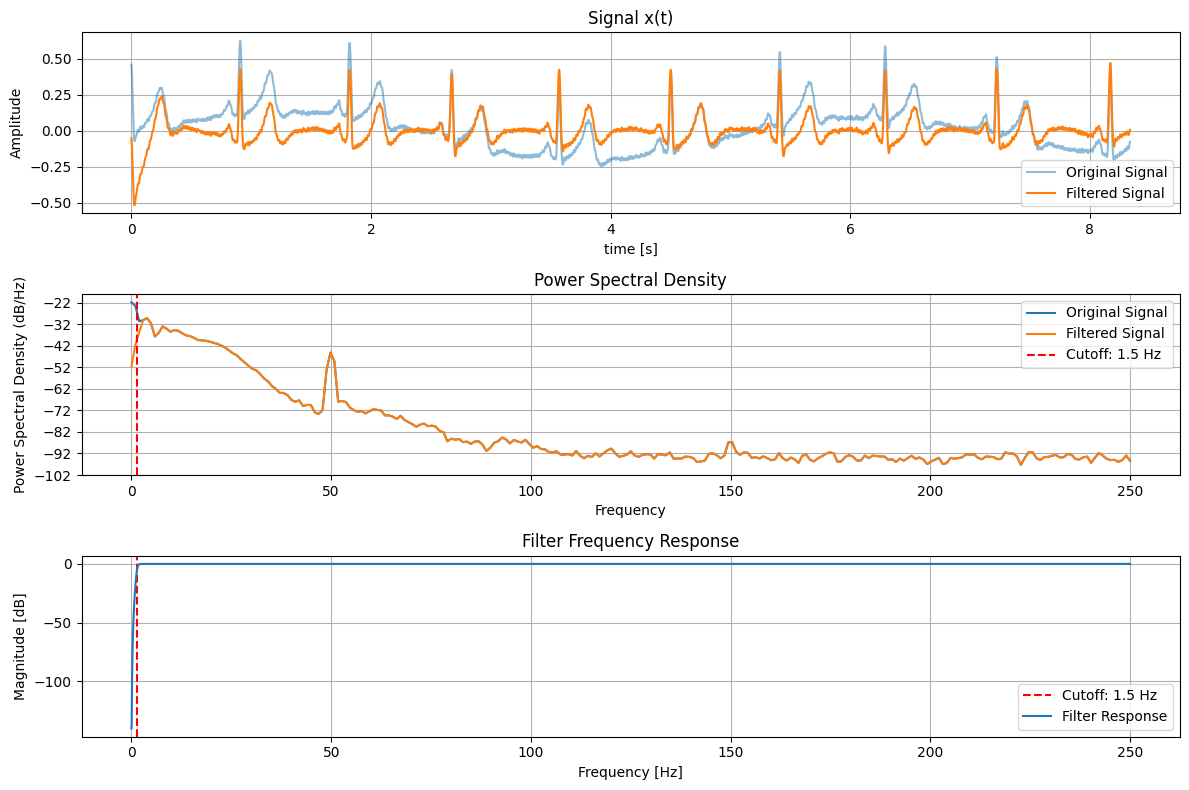

In [451]:
plot_signal_and_psd(t, ecg_signal, ecg_filtered, fs, cutoffs, b, a)

Next Filter will be a low pass filter that blocks frequencies above 150 Hz, this value was choosen based on standard established by American Heart Association. FIR was choosen to get rid of higher values it's stronger than IIR.

In [452]:
# FIR filter design
numtaps = 256  # Number of filter taps (more taps = sharper filter)
cutoff = np.array([152])    # Cutoff frequency in Hz
fir_coeff = signal.firwin(numtaps, cutoff, fs=fs)

In [453]:
# Apply filter
ecg_filtered_2 = signal.lfilter(fir_coeff, 1.0, ecg_filtered)

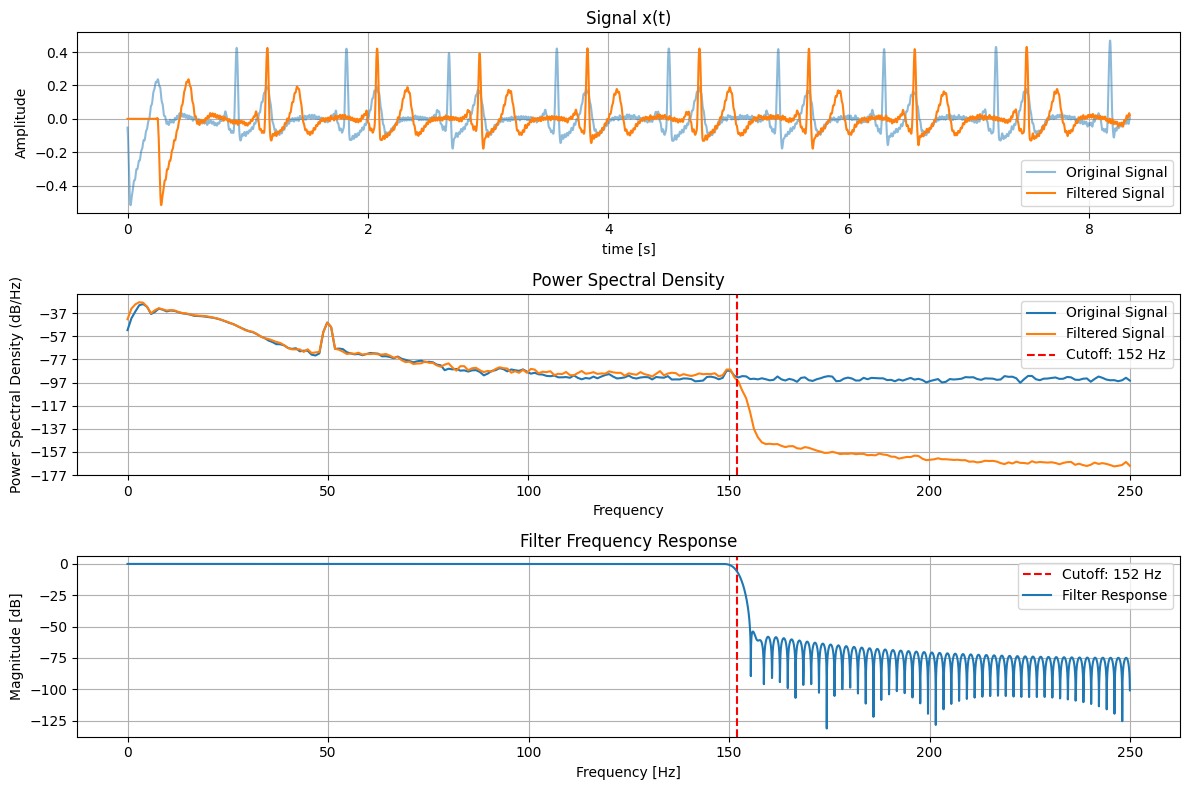

In [454]:
plot_signal_and_psd(t, ecg_filtered, ecg_filtered_2, fs, cutoff, fir_coeff, 1)

After applying window with FIR we lose a bit of signal to padding.

Last filter will be applied to delete electrical network interference, that appeares around 50-60Hz in ECG in our case it is exactly on 50Hz. IIR with order of 1 was applied around the peak. It gets rid off the peak but doesn't deform power spectrum.

In [459]:
order = 1
cutoffs = np.array([49,51])
b, a = signal.butter(order, cutoffs, fs=fs, btype='bandstop')

final_signal = signal.filtfilt(b, a, ecg_filtered_2[256//2:-256//2])

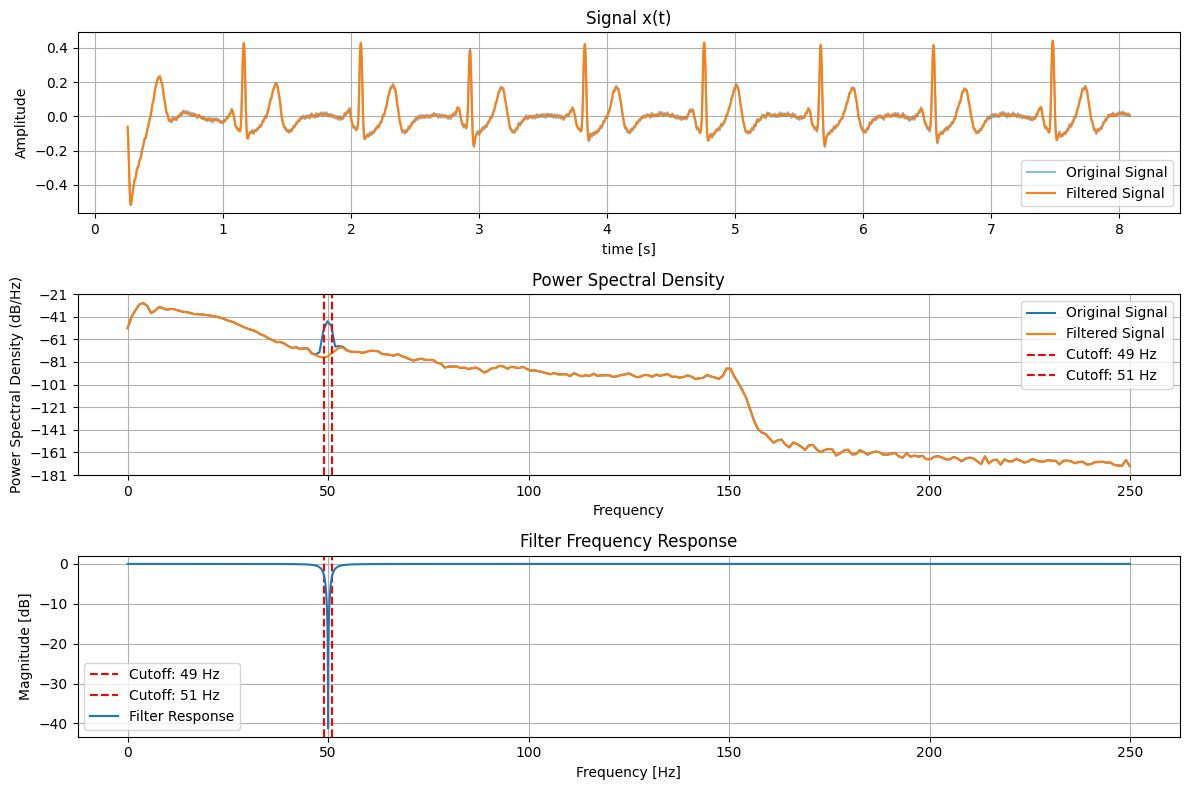

In [460]:
plot_signal_and_psd(t[256//2:-256//2], ecg_filtered_2[256//2:-256//2], final_signal, fs, cutoffs, b, a)

In [ ]:
we